In [1]:
import numpy as np
import pandas as pd
import os
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
import keras
import keras.backend as K
from keras.layers import Activation, Dense, LSTM, Dropout
from keras.models import Sequential, load_model
%matplotlib inline

from pylab import rcParams
import math
import xgboost
import time
from tqdm import tqdm
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.layers import GRU

from google.colab import drive
drive.mount('/content/drive')

np.random.seed(1234)
PYTHONHASHSEED = 0

Mounted at /content/drive


In [9]:
# # Data cleaning
# data_train = pd.read_csv('/content/drive/MyDrive/Amath 445 Project/train_FD001.txt', sep=" ", header=None)
# data_test = pd.read_csv('/content/drive/MyDrive/Amath 445 Project/test_FD001.txt', sep=" ", header=None)
# data_train

# # Add the column names
# columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
#            'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]
# # Drop the last two columns as they are unnamed and contain NaN values, which caused the length mismatch error.
# data_train = data_train.drop(data_train.columns[[26, 27]], axis=1)
# data_test = data_test.drop(data_test.columns[[26,27]], axis = 1)
# data_train.columns = columns
# data_test.columns = columns

# # Drop constant columns
# constant_columns = ['TRA','T2','P2','epr','farB','Nf_dmd','PCNfR_dmd']

# data_train = data_train.drop(columns=constant_columns,inplace= False)
# data_test = data_test.drop(columns=constant_columns,inplace= False)

# # Add target to train data
# def add_RUL(data, factor = 0, upper_bound = 130):
#     df = data.copy()
#     fd_RUL = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
#     fd_RUL.columns = ['unit_number','max']
#     df = df.merge(fd_RUL, on=['unit_number'], how='left')
#     df['RUL'] = df['max'] - df['time_in_cycles']

#     # Clip the RUL to the upper bound
#     df['RUL'] = df['RUL'].clip(upper=upper_bound)

#     df.drop(columns=['max'], inplace=True)
#     return df[df['time_in_cycles'] > factor]

# data_train = add_RUL(data_train)

## Basic RNN

In [31]:
# ---------------------------------------------------------
# 1. Data Loading
# ---------------------------------------------------------
base_path = '/content/drive/MyDrive/Amath 445 Project/'
data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)

columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32']

data_train = data_train.iloc[:, :26]
data_test = data_test.iloc[:, :26]
data_train.columns = columns
data_test.columns = columns

# Drop constant columns (sensors that don't change)
constant_columns = ['TRA','T2','P2','epr','farB','Nf_dmd','PCNfR_dmd']
data_train.drop(columns=constant_columns, inplace=True)
data_test.drop(columns=constant_columns, inplace=True)

# ---------------------------------------------------------
# 2. Piecewise Linear RUL Target Generation
# ---------------------------------------------------------
def add_piecewise_RUL(df, upper_bound=130):
    """Calculates RUL and clips it to the upper bound as per Heimes."""
    rul_data = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    rul_data.columns = ['unit_number', 'max_cycles']
    df = df.merge(rul_data, on=['unit_number'], how='left')
    df['RUL'] = df['max_cycles'] - df['time_in_cycles']

    # Clip the RUL to match the paper's target limit
    df['RUL'] = df['RUL'].clip(upper=upper_bound)

    df.drop(columns=['max_cycles'], inplace=True)
    return df

data_train = add_piecewise_RUL(data_train, upper_bound=130) # [cite: 147]

# ---------------------------------------------------------
# 3. Feature Scaling
# ---------------------------------------------------------
# We only scale the sensor and setting features, NOT unit_number, time, or RUL
features_to_scale = data_train.columns.difference(['unit_number', 'time_in_cycles', 'RUL'])

scaler = MinMaxScaler()
# Fit on training data ONLY to prevent data leakage
data_train[features_to_scale] = scaler.fit_transform(data_train[features_to_scale])
data_test[features_to_scale] = scaler.transform(data_test[features_to_scale])

# ---------------------------------------------------------
# 4. Sequence Generation (Sliding Window)
# ---------------------------------------------------------
sequence_length = 30 # Number of time steps to look back

def generate_sequences(df, seq_length, seq_cols):
    """Extracts 3D tensors of shape (samples, time_steps, features) per unit."""
    data_array = df[seq_cols].values
    num_elements = data_array.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length), range(seq_length, num_elements)):
        yield data_array[start:stop, :]

def generate_labels(df, seq_length, label_col):
    """Extracts the corresponding RUL target for each sequence."""
    data_array = df[label_col].values
    num_elements = data_array.shape[0]
    return data_array[seq_length:num_elements]

sequence_cols = features_to_scale.tolist()

# Generate Training Sequences
x_train, y_train = [], []
for unit in data_train['unit_number'].unique():
    unit_data = data_train[data_train['unit_number'] == unit]

    # We only grab sequences if the unit has enough data cycles
    if len(unit_data) >= sequence_length:
        x_train.extend(list(generate_sequences(unit_data, sequence_length, sequence_cols)))
        y_train.extend(list(generate_labels(unit_data, sequence_length, ['RUL'])))

x_train = np.array(x_train)
y_train = np.array(y_train)

print(f"Training Tensor Shape: {x_train.shape}") # Should be (samples, 30, 17)

# ---------------------------------------------------------
# 5. Model Architecture (Matching Heimes Paper)
# ---------------------------------------------------------
model = Sequential()

# Recurrent connection layer
# units=5 keeps the parameter count extremely low to match the paper's ~150 weights constraint
model.add(SimpleRNN(units=5,
                    input_shape=(x_train.shape[1], x_train.shape[2]),
                    activation='tanh',
                    return_sequences=False))

# Feed-forward connections
model.add(Dense(units=5, activation='relu'))
model.add(Dense(units=1, activation='linear')) # Output layer for RUL estimation

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

# Summary to verify the weight/parameter count (Should be around ~150)
model.summary()

# ---------------------------------------------------------
# 6. Training
# ---------------------------------------------------------
history = model.fit(x_train, y_train,
                    epochs=50,
                    batch_size=64,
                    validation_split=0.1,
                    verbose=1)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2977/4022314525.py:5: SyntaxWarning: invalid escape sequence '\s'
  data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_2977/4022314525.py:6: SyntaxWarning: invalid escape sequence '\s'
  data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_2977/4022314525.py:7: SyntaxWarning: invalid escape sequence '\s'
  actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)


Training Tensor Shape: (17631, 30, 17)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 5)              │           115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 8046.0684 - mae: 78.6132 - val_loss: 8427.9092 - val_mae: 81.0218
Epoch 2/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7056.5142 - mae: 72.5339 - val_loss: 7263.4390 - val_mae: 74.2469
Epoch 3/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5891.7666 - mae: 65.3261 - val_loss: 5943.5571 - val_mae: 66.4398
Epoch 4/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4683.8809 - mae: 57.7561 - val_loss: 4659.7012 - val_mae: 58.6588
Epoch 5/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3611.8247 - mae: 50.8891 - val_loss: 3583.0264 - val_mae: 51.8856
Epoch 6/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2800.8967 - mae: 45.5574 - val_loss: 2808.2344 - val_mae: 46.7214
Epoch 7/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2287.3640 - mae: 41.9876 - val_loss: 2335.5596 - val_mae: 43.2814
Epoch 8/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2022.8551 - mae: 39.9718 - val_loss: 2092.9231 - val_ma

551/551 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

--- Model Evaluation Results ---
| Metric              |   Train Data |   Test Data |
|:--------------------|-------------:|------------:|
| MSE                 |     395.4610 |    367.0650 |
| MAE                 |      15.2141 |     13.1527 |
| Accuracy (R2 Score) |       0.7893 |      0.7874 |


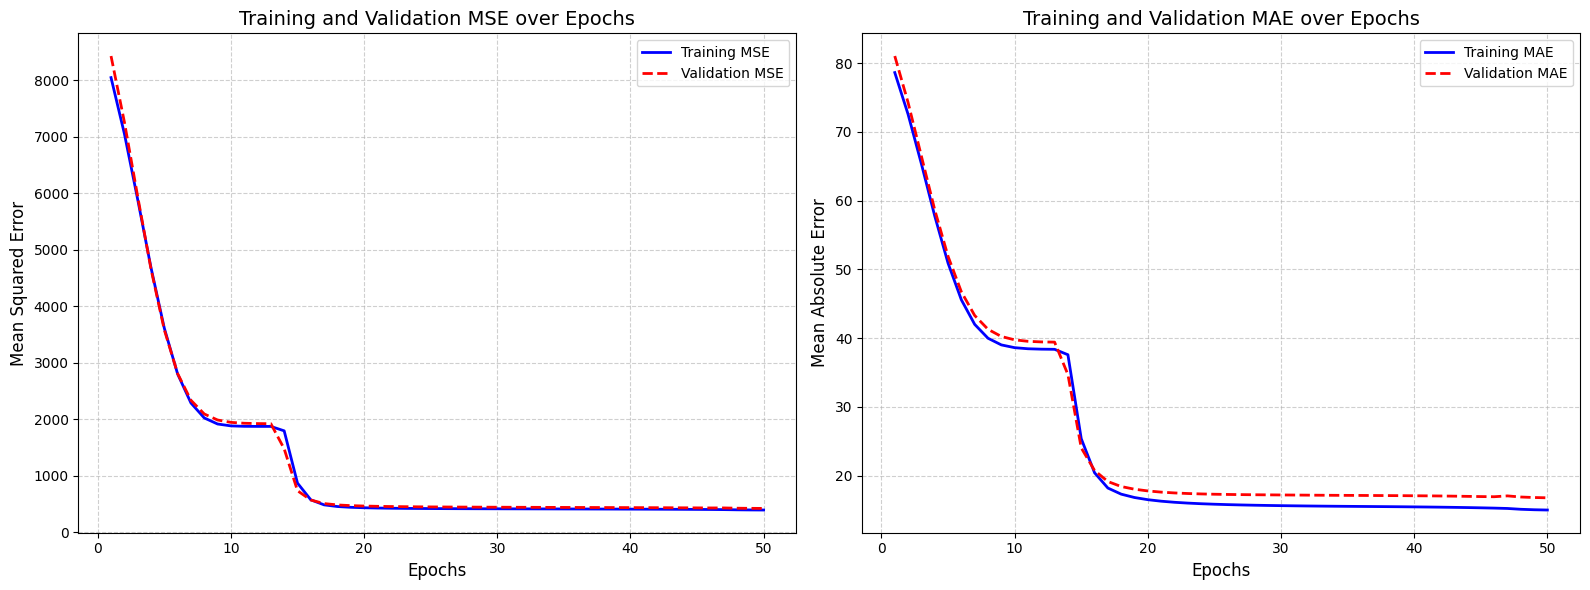

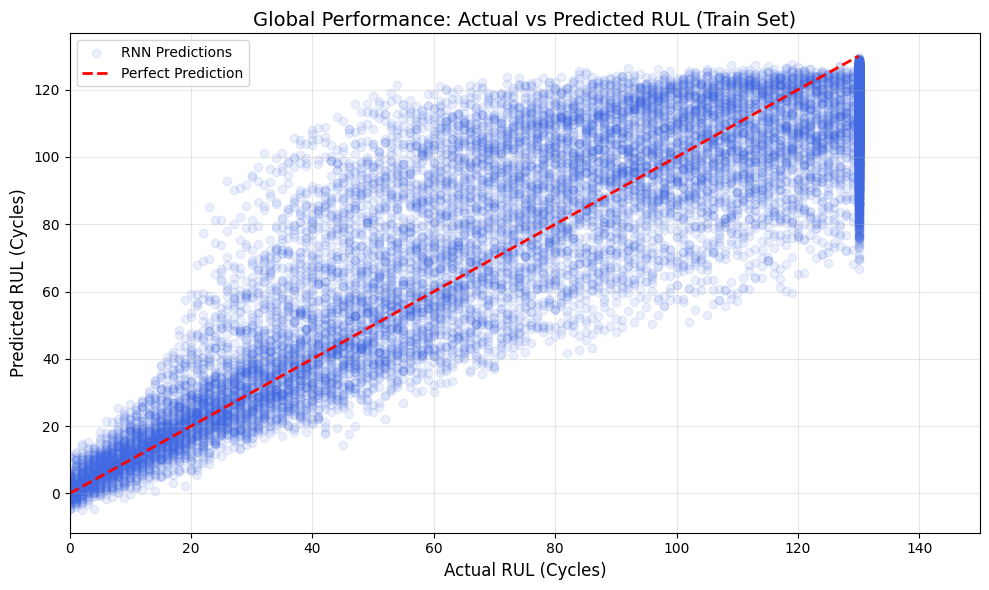

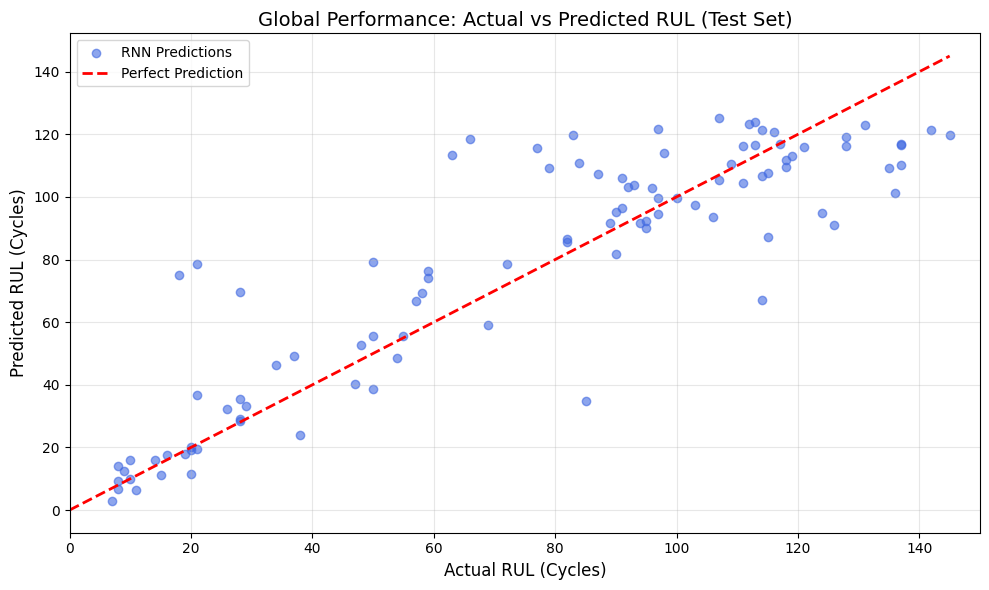

In [33]:
# ---------------------------------------------------------
# 7. Test Data Sequence Generation
# ---------------------------------------------------------
# We only need the *last* sequence of length 'sequence_length' for each test engine
x_test = []
test_units = data_test['unit_number'].unique()

for unit in test_units:
    unit_data = data_test[data_test['unit_number'] == unit]
    data_array = unit_data[sequence_cols].values

    # Extract the final sequence of the engine's run
    if len(unit_data) >= sequence_length:
        x_test.append(data_array[-sequence_length:, :])
    else:
        # Pad with edge values if an engine's history is shorter than the sequence length
        pad_size = sequence_length - len(unit_data)
        padded_data = np.pad(data_array, ((pad_size, 0), (0, 0)), mode='edge')
        x_test.append(padded_data)

x_test = np.array(x_test)

# The actual_rul file contains one column with the true RUL for the test engines
y_test = actual_rul.iloc[:, 0].values

# ---------------------------------------------------------
# 8. Evaluation & Metrics Table
# ---------------------------------------------------------
# Generate predictions and strictly force a 1D shape using .reshape(-1)
y_train_pred = model.predict(x_train).reshape(-1)
y_test_pred = model.predict(x_test).reshape(-1)
y_test_pred_rnn = y_test_pred.copy()

# Ensure the targets are also strictly 1D
y_train_true = y_train.reshape(-1)
y_test_true = y_test.reshape(-1)

# Calculate Train Metrics
mse_train = mean_squared_error(y_train_true, y_train_pred)
mae_train = mean_absolute_error(y_train_true, y_train_pred)
acc_train = r2_score(y_train_true, y_train_pred)

# Calculate Test Metrics
mse_test = mean_squared_error(y_test_true, y_test_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)
acc_test = r2_score(y_test_true, y_test_pred)

# Create and print the results table
results_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'Accuracy (R2 Score)'],
    'Train Data': [mse_train, mae_train, acc_train],
    'Test Data': [mse_test, mae_test, acc_test]
})

print("\n--- Model Evaluation Results ---")
print(results_df.to_markdown(index=False, floatfmt=".4f"))

# # ---------------------------------------------------------
# # 9. Plotting Target vs. Predicted RUL
# # ---------------------------------------------------------
# def plot_sorted_rul(y_true, y_pred, title):
#     """Plots the Target RUL (red) vs Predicted RUL (blue) sorted by the Target RUL."""

#     # Get the indices that would sort the true RUL in increasing order
#     sort_indices = np.argsort(y_true)

#     # Sort both arrays using the same indices
#     y_true_sorted = y_true[sort_indices]
#     y_pred_sorted = y_pred[sort_indices]

#     plt.figure(figsize=(12, 6))

#     # Plot predicted first so the true line sits cleanly on top
#     plt.plot(y_pred_sorted, color='blue', alpha=0.6, label='Predicted RUL')
#     plt.plot(y_true_sorted, color='red', linewidth=2, label='Target RUL')

#     plt.title(title, fontsize=14)
#     plt.xlabel('Samples (Sorted by Target RUL)', fontsize=12)
#     plt.ylabel('Remaining Useful Life (Cycles)', fontsize=12)
#     plt.legend(loc='upper left')
#     plt.grid(True, linestyle='--', alpha=0.5)

#     plt.tight_layout()
#     plt.show()

# # Generate the two requested plots
# plot_sorted_rul(y_train_true, y_train_pred, 'Train Data: Target vs. Predicted RUL')
# plot_sorted_rul(y_test_true, y_test_pred, 'Test Data: Target vs. Predicted RUL')

# ---------------------------------------------------------
# 10. Plotting Learning Curves (MSE and MAE vs. Epochs)
# ---------------------------------------------------------

def plot_learning_curves(history):
    """Plots the training and validation MSE and MAE over epochs."""

    # Extract metrics from the Keras history object
    # 'loss' maps to MSE because we compiled with loss='mean_squared_error'
    mse = history.history['loss']
    val_mse = history.history['val_loss']

    mae = history.history['mae']
    val_mae = history.history['val_mae']

    epochs = range(1, len(mse) + 1)

    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot 1: Mean Squared Error (Loss) ---
    ax1.plot(epochs, mse, 'b-', linewidth=2, label='Training MSE')
    ax1.plot(epochs, val_mse, 'r--', linewidth=2, label='Validation MSE')
    ax1.set_title('Training and Validation MSE over Epochs', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Mean Squared Error', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Plot 2: Mean Absolute Error (MAE) ---
    ax2.plot(epochs, mae, 'b-', linewidth=2, label='Training MAE')
    ax2.plot(epochs, val_mae, 'r--', linewidth=2, label='Validation MAE')
    ax2.set_title('Training and Validation MAE over Epochs', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Mean Absolute Error', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Generate the learning curve plots
plot_learning_curves(history)

# ---------------------------------------------------------
# 11. Plotting Actual vs. Predicted RUL (Scatter)
# ---------------------------------------------------------

def plot_actual_vs_predicted(y_true, y_pred, title, alpha):
    """Plots a scatter plot of Actual vs Predicted RUL with a 1:1 ideal line."""
    plt.figure(figsize=(10, 6))

    # Plot the predictions with low alpha (transparency) to see density
    plt.scatter(y_true, y_pred, alpha=alpha, color='royalblue', label='RNN Predictions')

    # Plot the ideal 1:1 line (where predicted exactly matches actual)
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

    plt.title(title, fontsize=14)
    plt.xlabel('Actual RUL (Cycles)', fontsize=12)
    plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xlim(0,150)

    plt.tight_layout()
    plt.show()

# Generate the scatter plots for both Train and Test data
plot_actual_vs_predicted(y_train_true, y_train_pred, 'Global Performance: Actual vs Predicted RUL (Train Set)', 0.1)
plot_actual_vs_predicted(y_test_true, y_test_pred, 'Global Performance: Actual vs Predicted RUL (Test Set)', 0.6)

Model performance metrics seems decent, however there is room for improvement:  

Over-estimating RUL is costly. We would want to penalize such predictions.  

The error function will be modified for the modified RNN model.

## RNN with penalty term against over-predictions of RUL (LSTM)

In [38]:
# ---------------------------------------------------------
# 1. Data Loading
# ---------------------------------------------------------
base_path = '/content/drive/MyDrive/Amath 445 Project/'
data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)

columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32']

data_train = data_train.iloc[:, :26]
data_test = data_test.iloc[:, :26]
data_train.columns = columns
data_test.columns = columns

# Drop constant columns (sensors that don't change)
constant_columns = ['TRA','T2','P2','epr','farB','Nf_dmd','PCNfR_dmd']
data_train.drop(columns=constant_columns, inplace=True)
data_test.drop(columns=constant_columns, inplace=True)

# ---------------------------------------------------------
# 2. Data Smoothing (Exponential Moving Average)
# ---------------------------------------------------------
features_to_process = data_train.columns.difference(['unit_number', 'time_in_cycles'])

# Apply EMA to smooth high-frequency sensor noise per unit
data_train[features_to_process] = data_train.groupby('unit_number')[features_to_process].transform(lambda x: x.ewm(span=10, adjust=False).mean())
data_test[features_to_process] = data_test.groupby('unit_number')[features_to_process].transform(lambda x: x.ewm(span=10, adjust=False).mean())

# ---------------------------------------------------------
# 3. Piecewise Linear RUL Target Generation
# ---------------------------------------------------------
def add_piecewise_RUL(df, upper_bound=130):
    rul_data = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    rul_data.columns = ['unit_number', 'max_cycles']
    df = df.merge(rul_data, on=['unit_number'], how='left')
    df['RUL'] = df['max_cycles'] - df['time_in_cycles']
    df['RUL'] = df['RUL'].clip(upper=upper_bound)
    df.drop(columns=['max_cycles'], inplace=True)
    return df

data_train = add_piecewise_RUL(data_train, upper_bound=130)

# ---------------------------------------------------------
# 4. Feature Scaling
# ---------------------------------------------------------
scaler = MinMaxScaler()
# Fit ONLY on training data
data_train[features_to_process] = scaler.fit_transform(data_train[features_to_process])
data_test[features_to_process] = scaler.transform(data_test[features_to_process])

# ---------------------------------------------------------
# 5. Sequence Generation (Sliding Window)
# ---------------------------------------------------------
sequence_length = 30
sequence_cols = features_to_process.tolist()

def generate_sequences(df, seq_length, seq_cols):
    data_array = df[seq_cols].values
    num_elements = data_array.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length), range(seq_length, num_elements)):
        yield data_array[start:stop, :]

def generate_labels(df, seq_length, label_col):
    data_array = df[label_col].values
    num_elements = data_array.shape[0]
    return data_array[seq_length:num_elements]

x_train, y_train = [], []
for unit in data_train['unit_number'].unique():
    unit_data = data_train[data_train['unit_number'] == unit]
    if len(unit_data) >= sequence_length:
        x_train.extend(list(generate_sequences(unit_data, sequence_length, sequence_cols)))
        y_train.extend(list(generate_labels(unit_data, sequence_length, ['RUL'])))

x_train = np.array(x_train)
y_train = np.array(y_train).reshape(-1)

# Generate Sample Weights: De-prioritize the flatline region (RUL = 130)
sample_weights = np.where(y_train == 130, 0.1, 1.0)

# ---------------------------------------------------------
# 6. Extract Test Sequences (Last sequence only)
# ---------------------------------------------------------
x_test = []
test_units = data_test['unit_number'].unique()

for unit in test_units:
    unit_data = data_test[data_test['unit_number'] == unit]
    data_array = unit_data[sequence_cols].values
    if len(unit_data) >= sequence_length:
        x_test.append(data_array[-sequence_length:, :])
    else:
        pad_size = sequence_length - len(unit_data)
        padded_data = np.pad(data_array, ((pad_size, 0), (0, 0)), mode='edge')
        x_test.append(padded_data)

x_test = np.array(x_test)
y_test = actual_rul.iloc[:, 0].values.reshape(-1)

# ---------------------------------------------------------
# 7. Model Architecture & Custom Loss (AMSE)
# ---------------------------------------------------------

def asymmetric_mse(penalty_factor=3.0):
    """Penalizes over-estimations (predicted > true) more heavily."""
    def loss(y_true, y_pred):
        # Cast to float32 to prevent any internal type mismatch errors
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        error = y_true - y_pred

        # Use tf.where instead of K.where
        squared_error = tf.square(error)
        penalized_error = tf.where(error < 0, penalty_factor * squared_error, squared_error)

        return tf.reduce_mean(penalized_error)
    return loss

model = Sequential()
# Upgraded from SimpleRNN to LSTM to prevent vanishing gradients
model.add(LSTM(units=15, input_shape=(x_train.shape[1], x_train.shape[2]), return_sequences=False))
model.add(Dense(units=5, activation='relu'))
model.add(Dense(units=1, activation='linear'))

model.compile(loss=asymmetric_mse(penalty_factor=3.0), optimizer='adam', metrics=['mae'])
model.summary()

# ---------------------------------------------------------
# 8. Training
# ---------------------------------------------------------
history = model.fit(x_train, y_train,
                    epochs=50,
                    batch_size=64,
                    validation_split=0.1,
                    sample_weight=sample_weights, # Apply the sample weights here
                    verbose=1)

# ---------------------------------------------------------
# 9. Evaluation & Metrics Table
# ---------------------------------------------------------
y_train_pred = model.predict(x_train).reshape(-1)
y_test_pred = model.predict(x_test).reshape(-1)
y_test_pred_lstm = y_test_pred.copy()

mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
acc_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
acc_test = r2_score(y_test, y_test_pred)

results_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'Accuracy (R2 Score)'],
    'Train Data': [mse_train, mae_train, acc_train],
    'Test Data': [mse_test, mae_test, acc_test]
})

print("\n--- Upgraded Model Evaluation Results ---")
print(results_df.to_markdown(index=False, floatfmt=".4f"))

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2977/1829589966.py:5: SyntaxWarning: invalid escape sequence '\s'
  data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_2977/1829589966.py:6: SyntaxWarning: invalid escape sequence '\s'
  data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_2977/1829589966.py:7: SyntaxWarning: invalid escape sequence '\s'
  actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 15)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,066 (8.07 KB)

 Trainable params: 2,066 (8.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5642.2744 - mae: 74.9371 - val_loss: 3472.7063 - val_mae: 73.5847
Epoch 2/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 4117.3311 - mae: 62.1850 - val_loss: 2399.4651 - val_mae: 60.8162
Epoch 3/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2969.9861 - mae: 51.3090 - val_loss: 1873.4955 - val_mae: 51.1986
Epoch 4/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2069.7825 - mae: 41.3808 - val_loss: 973.7931 - val_mae: 38.2348
Epoch 5/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1029.4259 - mae: 28.2327 - val_loss: 540.2423 - val_mae: 27.7491
Epoch 6/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 603.9744 - mae: 21.0542 - val_loss: 382.7572 - val_mae: 22.5985
Epoch 7/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 423.2690 - mae: 17.0723 - val_loss: 305.8440 - val_mae: 19.3600
Epoch 8/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 349.4826 - mae: 14.9932 - val_loss: 297.4620 - val_mae: 

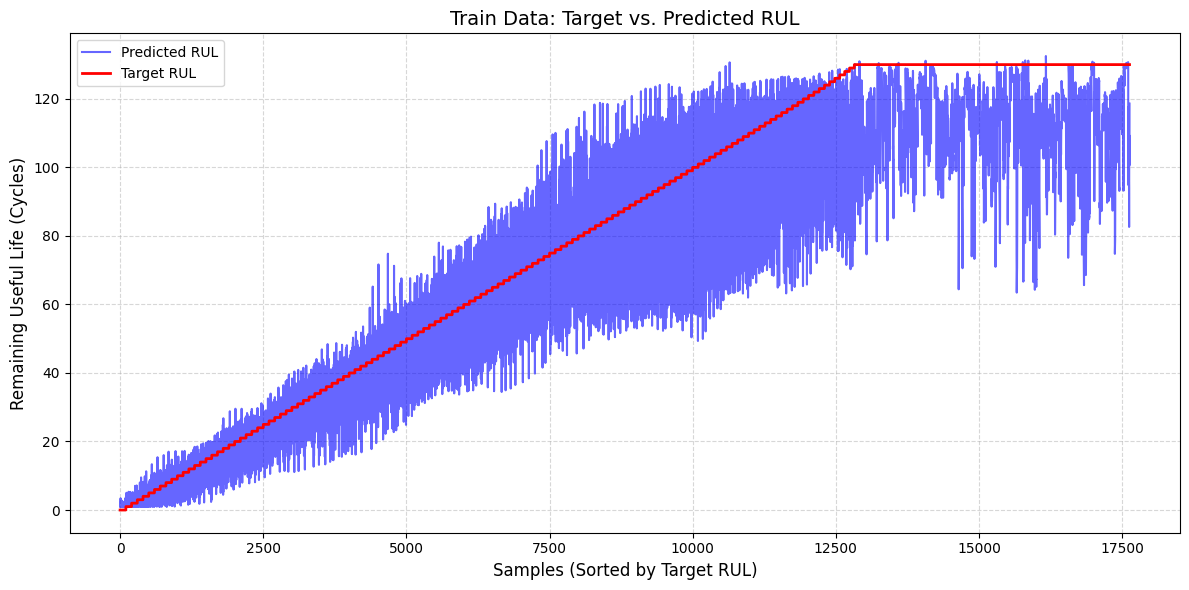

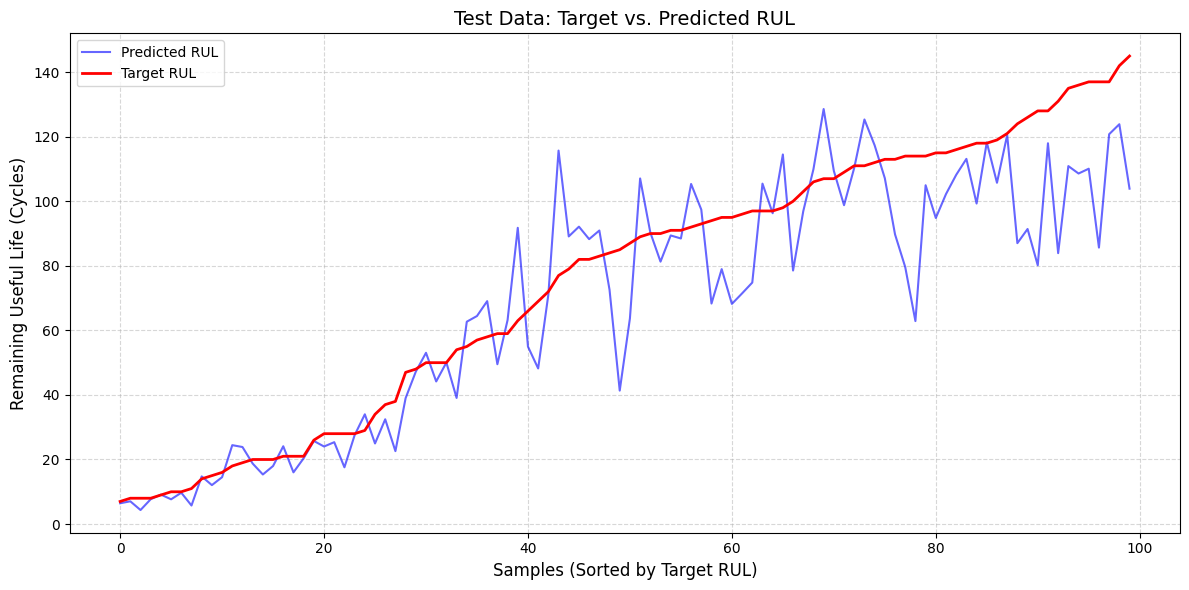

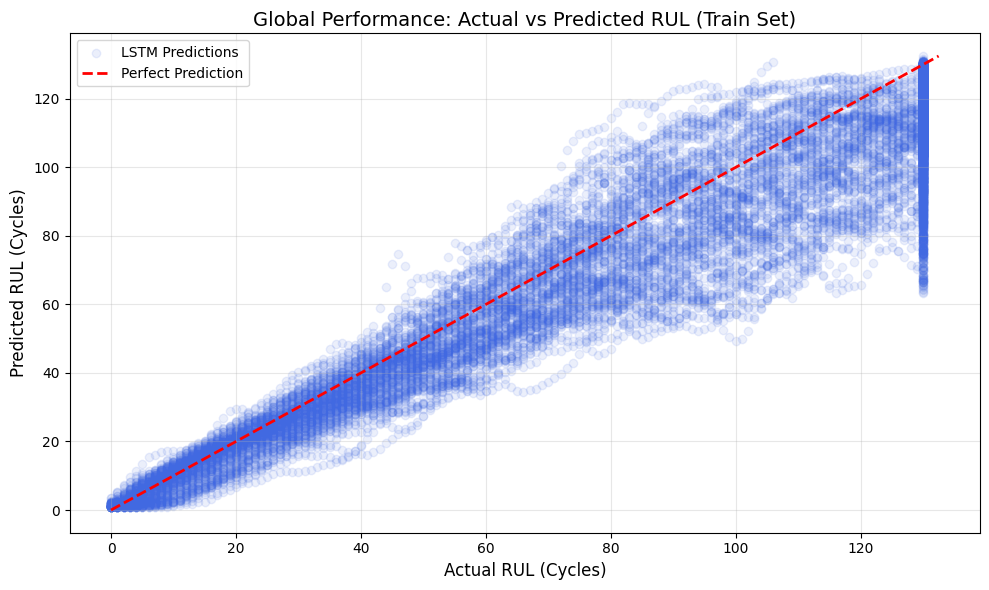

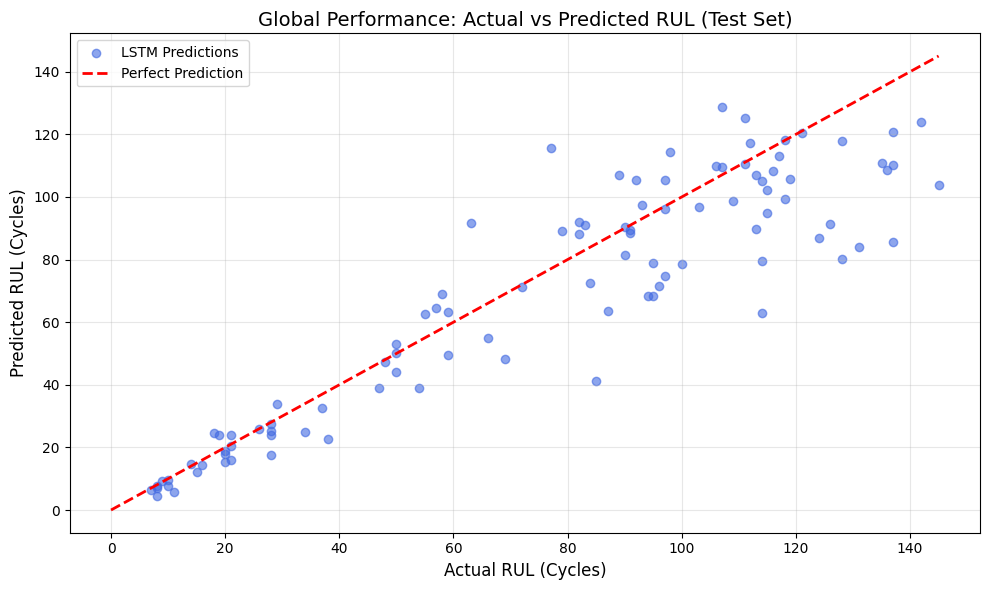

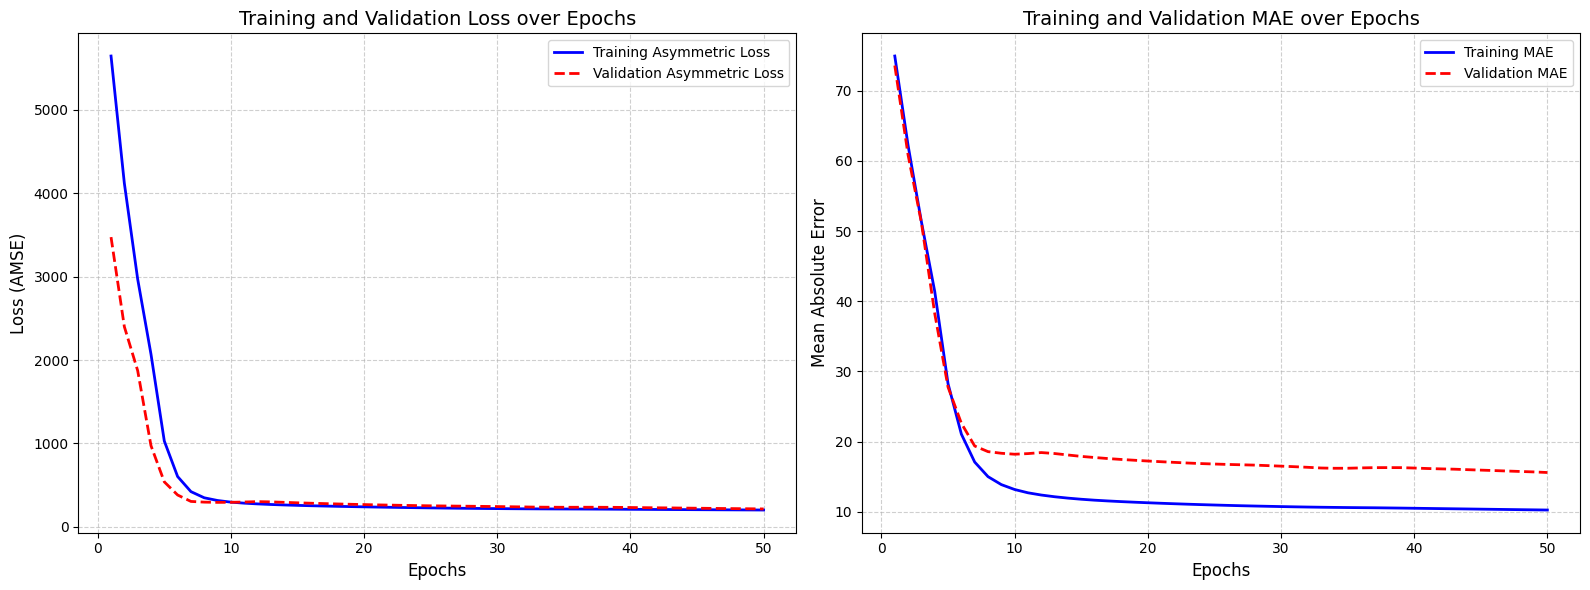

In [39]:
# ---------------------------------------------------------
# 10. Visualization Functions
# ---------------------------------------------------------
def plot_sorted_rul(y_true, y_pred, title):
    sort_indices = np.argsort(y_true)
    y_true_sorted = y_true[sort_indices]
    y_pred_sorted = y_pred[sort_indices]

    plt.figure(figsize=(12, 6))
    plt.plot(y_pred_sorted, color='blue', alpha=0.6, label='Predicted RUL')
    plt.plot(y_true_sorted, color='red', linewidth=2, label='Target RUL')
    plt.title(title, fontsize=14)
    plt.xlabel('Samples (Sorted by Target RUL)', fontsize=12)
    plt.ylabel('Remaining Useful Life (Cycles)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_actual_vs_predicted(y_true, y_pred, title, alpha):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=alpha, color='royalblue', label='LSTM Predictions')
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    plt.title(title, fontsize=14)
    plt.xlabel('Actual RUL (Cycles)', fontsize=12)
    plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_learning_curves(history):
    mse = history.history['loss']
    val_mse = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(mse) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(epochs, mse, 'b-', linewidth=2, label='Training Asymmetric Loss')
    ax1.plot(epochs, val_mse, 'r--', linewidth=2, label='Validation Asymmetric Loss')
    ax1.set_title('Training and Validation Loss over Epochs', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss (AMSE)', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(epochs, mae, 'b-', linewidth=2, label='Training MAE')
    ax2.plot(epochs, val_mae, 'r--', linewidth=2, label='Validation MAE')
    ax2.set_title('Training and Validation MAE over Epochs', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Mean Absolute Error', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Generate all plots
plot_sorted_rul(y_train, y_train_pred, 'Train Data: Target vs. Predicted RUL')
plot_sorted_rul(y_test, y_test_pred, 'Test Data: Target vs. Predicted RUL')
plot_actual_vs_predicted(y_train, y_train_pred, 'Global Performance: Actual vs Predicted RUL (Train Set)', 0.1)
plot_actual_vs_predicted(y_test, y_test_pred, 'Global Performance: Actual vs Predicted RUL (Test Set)', 0.6)
plot_learning_curves(history)

## RNN with penalty term against over-predictions of RUL (GRU)

In [26]:
# ---------------------------------------------------------
# 1. Data Loading
# ---------------------------------------------------------
base_path = '/content/drive/MyDrive/Amath 445 Project/'
data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)

columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32']

data_train = data_train.iloc[:, :26]
data_test = data_test.iloc[:, :26]
data_train.columns = columns
data_test.columns = columns

# Drop constant columns (sensors that don't change)
constant_columns = ['TRA','T2','P2','epr','farB','Nf_dmd','PCNfR_dmd']
data_train.drop(columns=constant_columns, inplace=True)
data_test.drop(columns=constant_columns, inplace=True)

# ---------------------------------------------------------
# 2. Data Smoothing (Exponential Moving Average)
# ---------------------------------------------------------
features_to_process = data_train.columns.difference(['unit_number', 'time_in_cycles'])

# Apply EMA to smooth high-frequency sensor noise per unit
data_train[features_to_process] = data_train.groupby('unit_number')[features_to_process].transform(lambda x: x.ewm(span=10, adjust=False).mean())
data_test[features_to_process] = data_test.groupby('unit_number')[features_to_process].transform(lambda x: x.ewm(span=10, adjust=False).mean())

# ---------------------------------------------------------
# 3. Piecewise Linear RUL Target Generation
# ---------------------------------------------------------
def add_piecewise_RUL(df, upper_bound=130):
    rul_data = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    rul_data.columns = ['unit_number', 'max_cycles']
    df = df.merge(rul_data, on=['unit_number'], how='left')
    df['RUL'] = df['max_cycles'] - df['time_in_cycles']
    df['RUL'] = df['RUL'].clip(upper=upper_bound)
    df.drop(columns=['max_cycles'], inplace=True)
    return df

data_train = add_piecewise_RUL(data_train, upper_bound=130)

# ---------------------------------------------------------
# 4. Feature Scaling
# ---------------------------------------------------------
scaler = MinMaxScaler()
# Fit ONLY on training data
data_train[features_to_process] = scaler.fit_transform(data_train[features_to_process])
data_test[features_to_process] = scaler.transform(data_test[features_to_process])

# ---------------------------------------------------------
# 5. Sequence Generation (Sliding Window)
# ---------------------------------------------------------
sequence_length = 30
sequence_cols = features_to_process.tolist()

def generate_sequences(df, seq_length, seq_cols):
    data_array = df[seq_cols].values
    num_elements = data_array.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length), range(seq_length, num_elements)):
        yield data_array[start:stop, :]

def generate_labels(df, seq_length, label_col):
    data_array = df[label_col].values
    num_elements = data_array.shape[0]
    return data_array[seq_length:num_elements]

x_train, y_train = [], []
for unit in data_train['unit_number'].unique():
    unit_data = data_train[data_train['unit_number'] == unit]
    if len(unit_data) >= sequence_length:
        x_train.extend(list(generate_sequences(unit_data, sequence_length, sequence_cols)))
        y_train.extend(list(generate_labels(unit_data, sequence_length, ['RUL'])))

x_train = np.array(x_train)
y_train = np.array(y_train).reshape(-1)

# Generate Sample Weights: De-prioritize the flatline region (RUL = 130)
sample_weights = np.where(y_train == 130, 0.1, 1.0)

# ---------------------------------------------------------
# 6. Extract Test Sequences (Last sequence only)
# ---------------------------------------------------------
x_test = []
test_units = data_test['unit_number'].unique()

for unit in test_units:
    unit_data = data_test[data_test['unit_number'] == unit]
    data_array = unit_data[sequence_cols].values
    if len(unit_data) >= sequence_length:
        x_test.append(data_array[-sequence_length:, :])
    else:
        pad_size = sequence_length - len(unit_data)
        padded_data = np.pad(data_array, ((pad_size, 0), (0, 0)), mode='edge')
        x_test.append(padded_data)

x_test = np.array(x_test)
y_test = actual_rul.iloc[:, 0].values.reshape(-1)

# ---------------------------------------------------------
# 7. Model Architecture (GRU) & Custom Loss
# ---------------------------------------------------------
model_gru = Sequential()
model_gru.add(GRU(units=15, input_shape=(x_train.shape[1], x_train.shape[2]), return_sequences=False))
model_gru.add(Dense(units=5, activation='relu'))
model_gru.add(Dense(units=1, activation='linear'))

# Compile with the custom asymmetric loss function
model_gru.compile(loss=asymmetric_mse(penalty_factor=3.0), optimizer='adam', metrics=['mae'])
print("\n--- GRU Model Summary ---")
model_gru.summary()

# ---------------------------------------------------------
# 8. Training the GRU
# ---------------------------------------------------------
history_gru = model_gru.fit(x_train, y_train,
                            epochs=50,
                            batch_size=64,
                            validation_split=0.1,
                            sample_weight=sample_weights,
                            verbose=1)

# Generate GRU Predictions
y_train_pred_gru = model_gru.predict(x_train).reshape(-1)
y_test_pred_gru = model_gru.predict(x_test).reshape(-1)

# ---------------------------------------------------------
# 8. Training
# ---------------------------------------------------------
history = model.fit(x_train, y_train,
                    epochs=50,
                    batch_size=64,
                    validation_split=0.1,
                    sample_weight=sample_weights, # Apply the sample weights here
                    verbose=1)

# ---------------------------------------------------------
# 9. Evaluation & Metrics Table
# ---------------------------------------------------------
y_train_pred = model.predict(x_train).reshape(-1)
y_test_pred = model.predict(x_test).reshape(-1)
y_test_pred_gru = y_test_pred.copy()

mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
acc_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
acc_test = r2_score(y_test, y_test_pred)

results_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'Accuracy (R2 Score)'],
    'Train Data': [mse_train, mae_train, acc_train],
    'Test Data': [mse_test, mae_test, acc_test]
})

print("\n--- Upgraded Model Evaluation Results ---")
print(results_df.to_markdown(index=False, floatfmt=".4f"))

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2977/2497776449.py:19: SyntaxWarning: invalid escape sequence '\s'
  data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_2977/2497776449.py:20: SyntaxWarning: invalid escape sequence '\s'
  data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_2977/2497776449.py:21: SyntaxWarning: invalid escape sequence '\s'
  actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)



--- GRU Model Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 15)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,616 (6.31 KB)

 Trainable params: 1,616 (6.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 6052.9756 - mae: 78.3059 - val_loss: 4140.2368 - val_mae: 80.5809
Epoch 2/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 5250.4087 - mae: 71.7555 - val_loss: 3419.4995 - val_mae: 73.0096
Epoch 3/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 4280.4541 - mae: 63.6307 - val_loss: 2656.7727 - val_mae: 64.2082
Epoch 4/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 3355.3792 - mae: 55.3149 - val_loss: 2051.0549 - val_mae: 55.8395
Epoch 5/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 2622.0889 - mae: 47.9204 - val_loss: 1622.3315 - val_mae: 48.5074
Epoch 6/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 1904.3843 - mae: 40.0465 - val_loss: 1016.8524 - val_mae: 39.0384
Epoch 7/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1159.8113 - mae: 30.3694 - val_loss: 614.5880 - val_mae: 30.7412
Epoch 8/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 718.7711 - mae: 23.2783 - val_loss: 391.7639 - val_

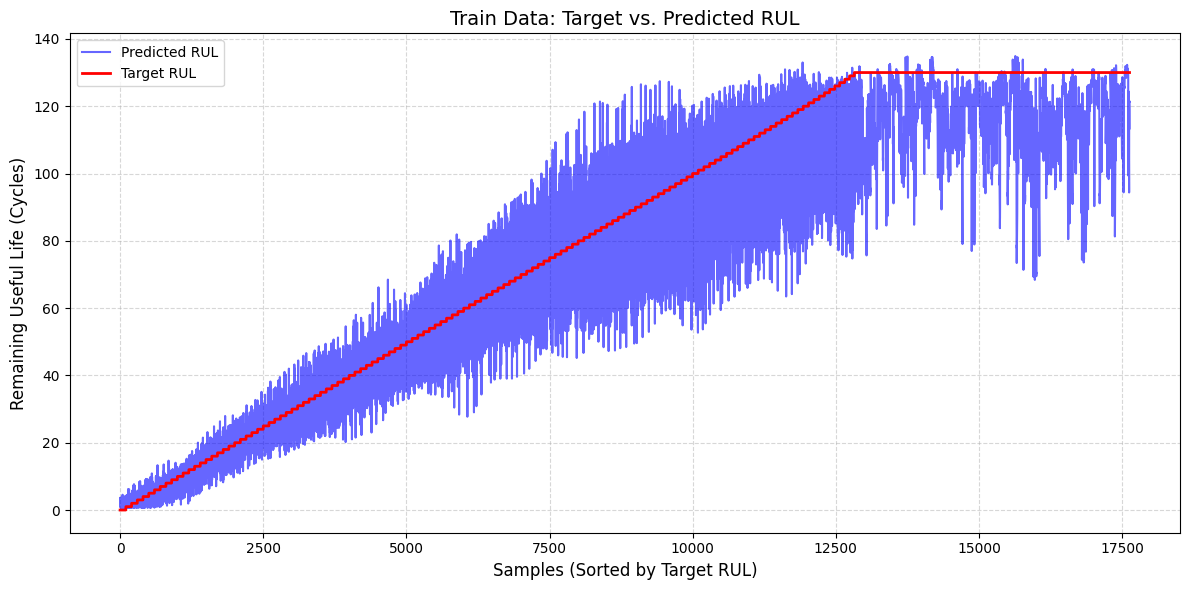

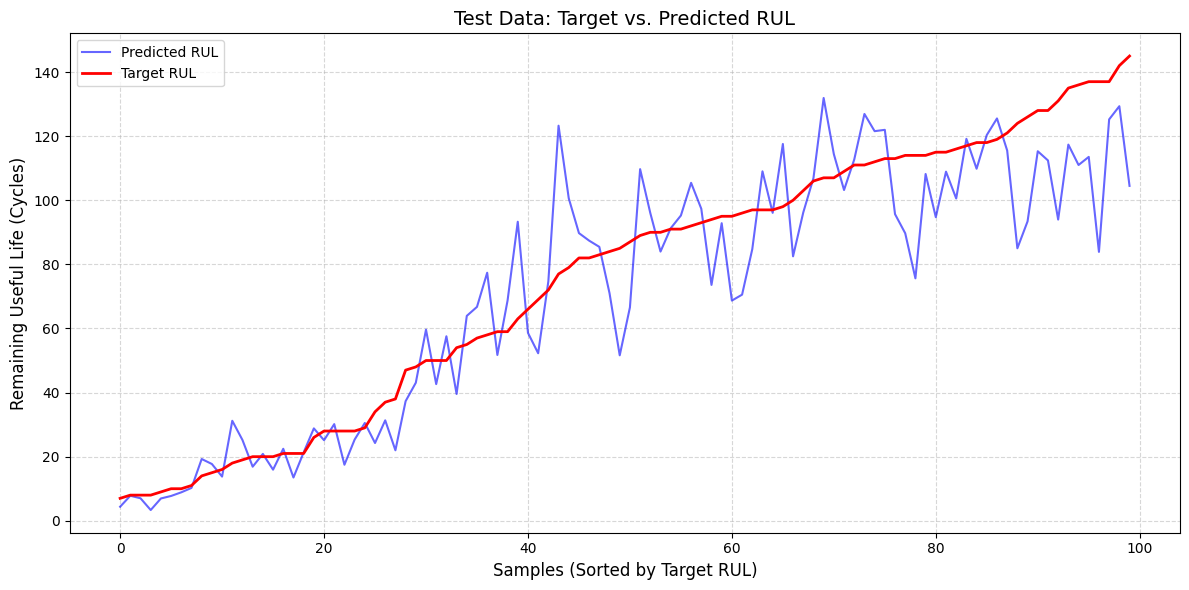

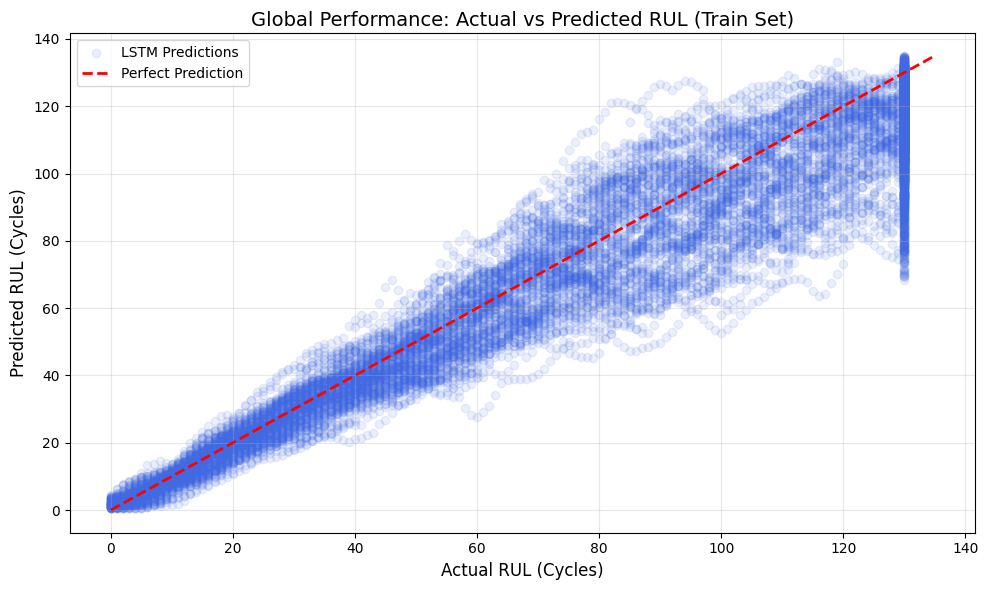

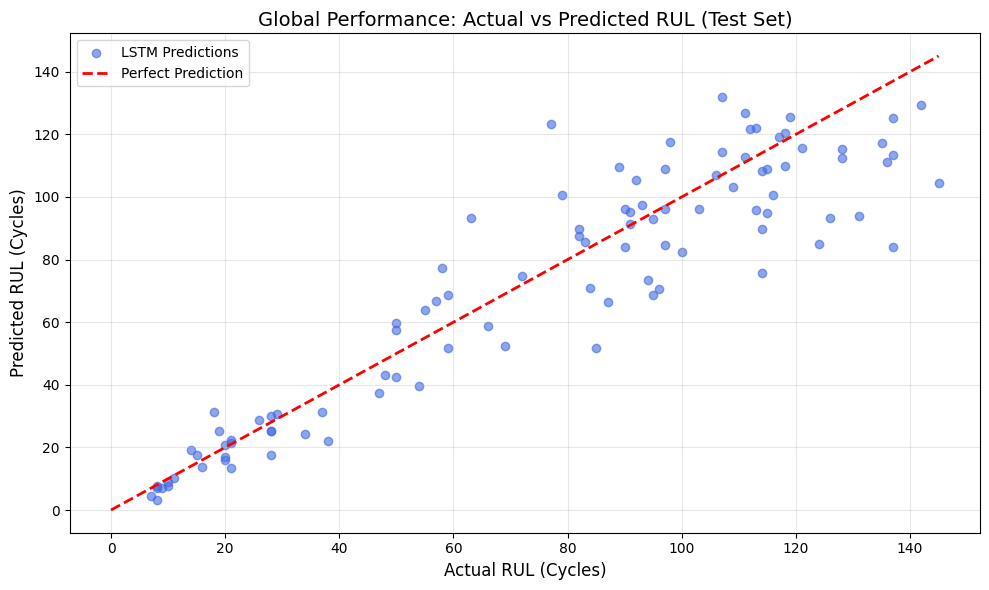

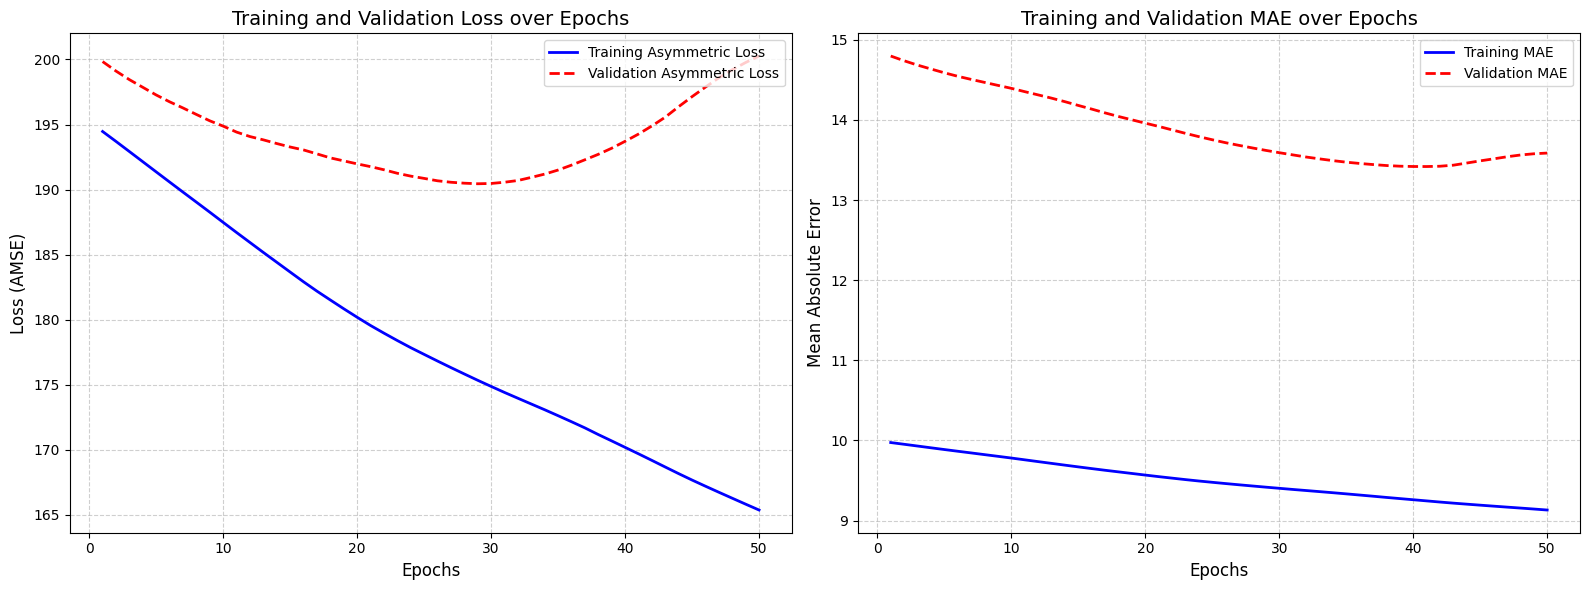

In [27]:
# ---------------------------------------------------------
# 10. Visualization Functions
# ---------------------------------------------------------
def plot_sorted_rul(y_true, y_pred, title):
    sort_indices = np.argsort(y_true)
    y_true_sorted = y_true[sort_indices]
    y_pred_sorted = y_pred[sort_indices]

    plt.figure(figsize=(12, 6))
    plt.plot(y_pred_sorted, color='blue', alpha=0.6, label='Predicted RUL')
    plt.plot(y_true_sorted, color='red', linewidth=2, label='Target RUL')
    plt.title(title, fontsize=14)
    plt.xlabel('Samples (Sorted by Target RUL)', fontsize=12)
    plt.ylabel('Remaining Useful Life (Cycles)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_actual_vs_predicted(y_true, y_pred, title, alpha):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=alpha, color='royalblue', label='LSTM Predictions')
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    plt.title(title, fontsize=14)
    plt.xlabel('Actual RUL (Cycles)', fontsize=12)
    plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_learning_curves(history):
    mse = history.history['loss']
    val_mse = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(mse) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(epochs, mse, 'b-', linewidth=2, label='Training Asymmetric Loss')
    ax1.plot(epochs, val_mse, 'r--', linewidth=2, label='Validation Asymmetric Loss')
    ax1.set_title('Training and Validation Loss over Epochs', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss (AMSE)', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(epochs, mae, 'b-', linewidth=2, label='Training MAE')
    ax2.plot(epochs, val_mae, 'r--', linewidth=2, label='Validation MAE')
    ax2.set_title('Training and Validation MAE over Epochs', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Mean Absolute Error', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Generate all plots
plot_sorted_rul(y_train, y_train_pred, 'Train Data: Target vs. Predicted RUL')
plot_sorted_rul(y_test, y_test_pred, 'Test Data: Target vs. Predicted RUL')
plot_actual_vs_predicted(y_train, y_train_pred, 'Global Performance: Actual vs Predicted RUL (Train Set)', 0.1)
plot_actual_vs_predicted(y_test, y_test_pred, 'Global Performance: Actual vs Predicted RUL (Test Set)', 0.6)
plot_learning_curves(history)

## GRU + early stopping

In [35]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, GRU
from tensorflow.keras.callbacks import EarlyStopping

# Set seeds for reproducibility
# np.random.seed(1234)
# tf.random.set_seed(1234)

# ---------------------------------------------------------
# 1. Data Loading
# ---------------------------------------------------------
base_path = '/content/drive/MyDrive/Amath 445 Project/'
data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)

columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32']

data_train = data_train.iloc[:, :26]
data_test = data_test.iloc[:, :26]
data_train.columns = columns
data_test.columns = columns

# Drop constant columns (sensors that don't change)
constant_columns = ['TRA','T2','P2','epr','farB','Nf_dmd','PCNfR_dmd']
data_train.drop(columns=constant_columns, inplace=True)
data_test.drop(columns=constant_columns, inplace=True)

# ---------------------------------------------------------
# 2. Data Smoothing (Exponential Moving Average)
# ---------------------------------------------------------
features_to_process = data_train.columns.difference(['unit_number', 'time_in_cycles'])

# Apply EMA to smooth high-frequency sensor noise per unit
data_train[features_to_process] = data_train.groupby('unit_number')[features_to_process].transform(lambda x: x.ewm(span=10, adjust=False).mean())
data_test[features_to_process] = data_test.groupby('unit_number')[features_to_process].transform(lambda x: x.ewm(span=10, adjust=False).mean())

# ---------------------------------------------------------
# 3. Piecewise Linear RUL Target Generation
# ---------------------------------------------------------
def add_piecewise_RUL(df, upper_bound=130):
    rul_data = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    rul_data.columns = ['unit_number', 'max_cycles']
    df = df.merge(rul_data, on=['unit_number'], how='left')
    df['RUL'] = df['max_cycles'] - df['time_in_cycles']
    df['RUL'] = df['RUL'].clip(upper=upper_bound)
    df.drop(columns=['max_cycles'], inplace=True)
    return df

data_train = add_piecewise_RUL(data_train, upper_bound=130)

# ---------------------------------------------------------
# 4. Feature Scaling
# ---------------------------------------------------------
scaler = MinMaxScaler()
# Fit ONLY on training data to prevent data leakage
data_train[features_to_process] = scaler.fit_transform(data_train[features_to_process])
data_test[features_to_process] = scaler.transform(data_test[features_to_process])

# ---------------------------------------------------------
# 5. Sequence Generation (Sliding Window)
# ---------------------------------------------------------
sequence_length = 30
sequence_cols = features_to_process.tolist()

def generate_sequences(df, seq_length, seq_cols):
    data_array = df[seq_cols].values
    num_elements = data_array.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length), range(seq_length, num_elements)):
        yield data_array[start:stop, :]

def generate_labels(df, seq_length, label_col):
    data_array = df[label_col].values
    num_elements = data_array.shape[0]
    return data_array[seq_length:num_elements]

x_train, y_train = [], []
for unit in data_train['unit_number'].unique():
    unit_data = data_train[data_train['unit_number'] == unit]
    if len(unit_data) >= sequence_length:
        x_train.extend(list(generate_sequences(unit_data, sequence_length, sequence_cols)))
        y_train.extend(list(generate_labels(unit_data, sequence_length, ['RUL'])))

x_train = np.array(x_train)
y_train = np.array(y_train).reshape(-1)

# Generate Sample Weights: De-prioritize the early-life flatline region (RUL = 130)
sample_weights = np.where(y_train == 130, 0.1, 1.0)

# ---------------------------------------------------------
# 6. Extract Test Sequences (Last sequence only)
# ---------------------------------------------------------
x_test = []
test_units = data_test['unit_number'].unique()

for unit in test_units:
    unit_data = data_test[data_test['unit_number'] == unit]
    data_array = unit_data[sequence_cols].values
    if len(unit_data) >= sequence_length:
        x_test.append(data_array[-sequence_length:, :])
    else:
        # Pad if an engine's history is shorter than the sequence length
        pad_size = sequence_length - len(unit_data)
        padded_data = np.pad(data_array, ((pad_size, 0), (0, 0)), mode='edge')
        x_test.append(padded_data)

x_test = np.array(x_test)
y_test = actual_rul.iloc[:, 0].values.reshape(-1)

# ---------------------------------------------------------
# 7. Model Architecture & Custom Loss (AMSE)
# ---------------------------------------------------------
def asymmetric_mse(penalty_factor=3.0):
    """Penalizes over-estimations (predicted > true) more heavily."""
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        error = y_true - y_pred
        squared_error = tf.square(error)
        penalized_error = tf.where(error < 0, penalty_factor * squared_error, squared_error)
        return tf.reduce_mean(penalized_error)
    return loss

model_gru_es = Sequential()
model_gru_es.add(GRU(units=15, input_shape=(x_train.shape[1], x_train.shape[2]), return_sequences=False))
model_gru_es.add(Dense(units=5, activation='relu'))
model_gru_es.add(Dense(units=1, activation='linear'))

model_gru_es.compile(loss=asymmetric_mse(penalty_factor=3.0), optimizer='adam', metrics=['mae'])
print("\n--- GRU Model Summary ---")
model_gru_es.summary()

# ---------------------------------------------------------
# 8. Training with Early Stopping
# ---------------------------------------------------------
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining GRU with Early Stopping...")
history = model_gru_es.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    sample_weight=sample_weights,
    callbacks=[early_stopper],
    verbose=1
)

# ---------------------------------------------------------
# 9. Evaluation & Metrics Table
# ---------------------------------------------------------
# Using the requested variable names
y_train_pred_gru_es = model_gru_es.predict(x_train).reshape(-1)
y_test_pred_gru_es = model_gru_es.predict(x_test).reshape(-1)

mse_train = mean_squared_error(y_train, y_train_pred_gru_es)
mae_train = mean_absolute_error(y_train, y_train_pred_gru_es)
acc_train = r2_score(y_train, y_train_pred_gru_es)

mse_test = mean_squared_error(y_test, y_test_pred_gru_es)
mae_test = mean_absolute_error(y_test, y_test_pred_gru_es)
acc_test = r2_score(y_test, y_test_pred_gru_es)

results_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'Accuracy (R2 Score)'],
    'Train Data': [mse_train, mae_train, acc_train],
    'Test Data': [mse_test, mae_test, acc_test]
})

print("\n--- GRU (Early Stopping) Evaluation Results ---")
print(results_df.to_markdown(index=False, floatfmt=".4f"))

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2977/1001010793.py:19: SyntaxWarning: invalid escape sequence '\s'
  data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_2977/1001010793.py:20: SyntaxWarning: invalid escape sequence '\s'
  data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_2977/1001010793.py:21: SyntaxWarning: invalid escape sequence '\s'
  actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)



--- GRU Model Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 15)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,616 (6.31 KB)

 Trainable params: 1,616 (6.31 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU with Early Stopping...
Epoch 1/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 5346.5303 - mae: 72.4746 - val_loss: 3178.9292 - val_mae: 70.3547
Epoch 2/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 3774.9839 - mae: 59.1463 - val_loss: 2202.5271 - val_mae: 57.9218
Epoch 3/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 2778.5007 - mae: 49.2026 - val_loss: 1765.6705 - val_mae: 49.3574
Epoch 4/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 2263.8982 - mae: 42.9035 - val_loss: 1583.1617 - val_mae: 43.6753
Epoch 5/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1810.8088 - mae: 37.5319 - val_loss: 872.4442 - val_mae: 34.5573
Epoch 6/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 844.3801 - mae: 25.2722 - val_loss: 428.3209 - val_mae: 24.0606
Epoch 7/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 458.2267 - mae: 18.0094 - val_loss: 312.7810 - val_mae: 19.8571
Epoch 8/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 342.8945 -

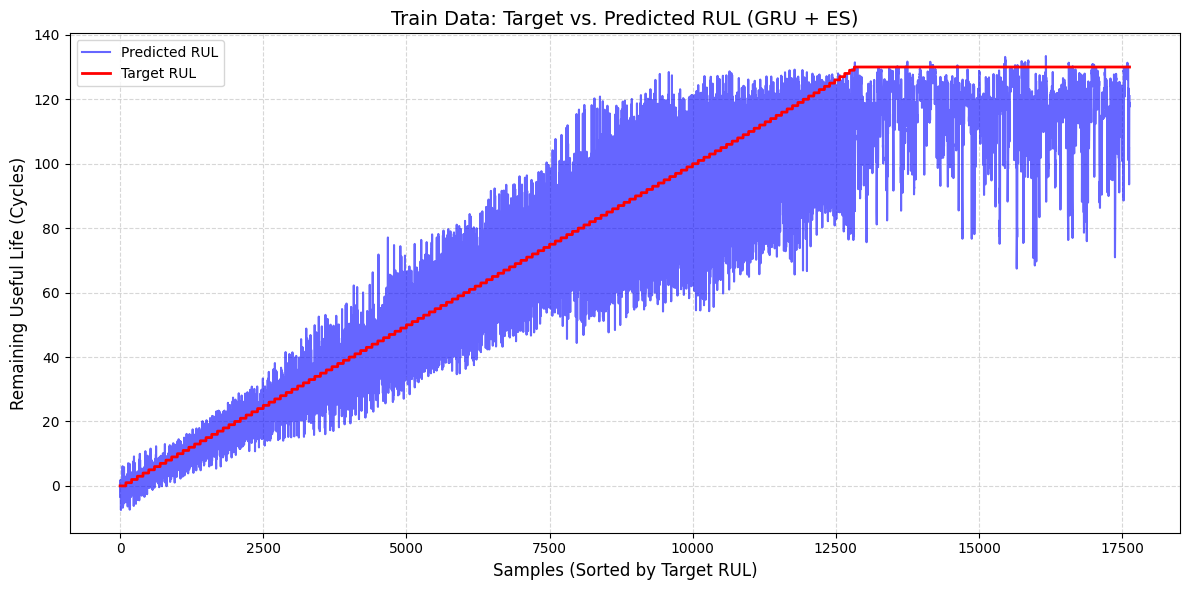

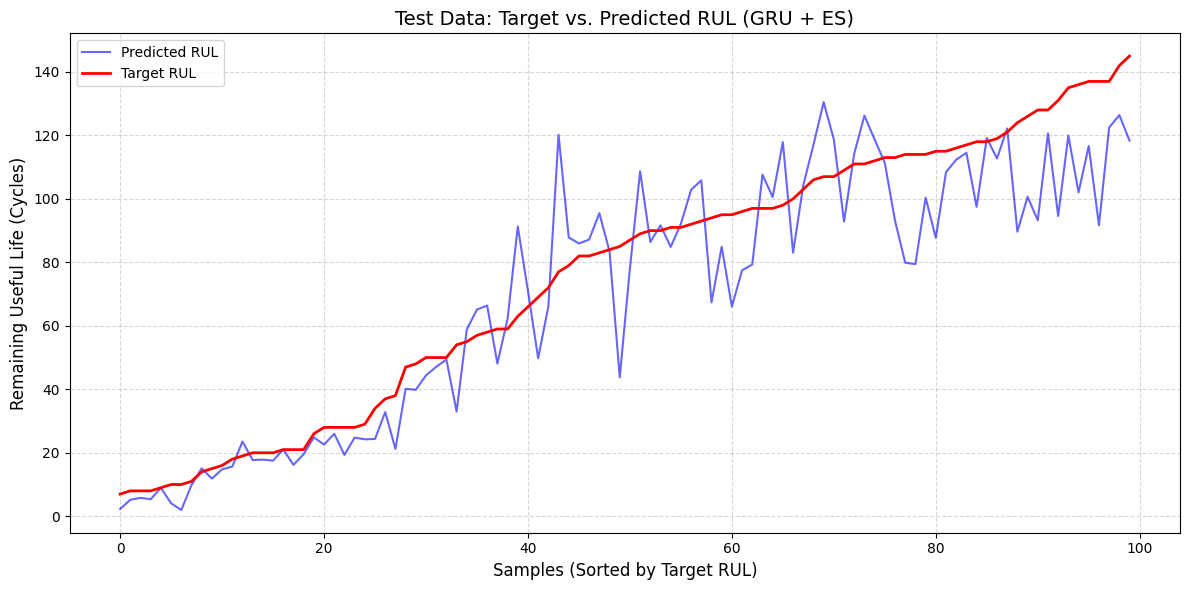

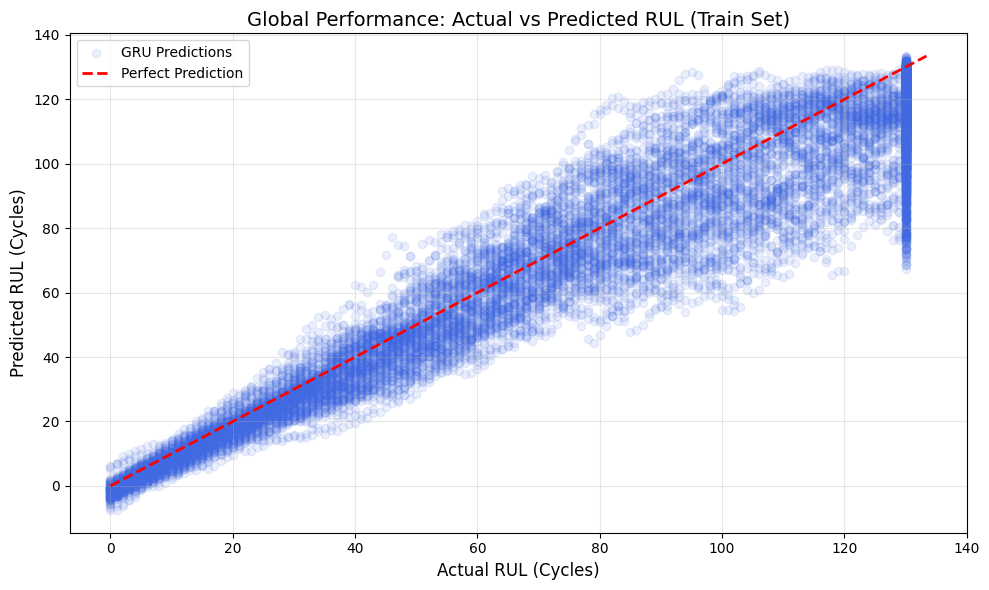

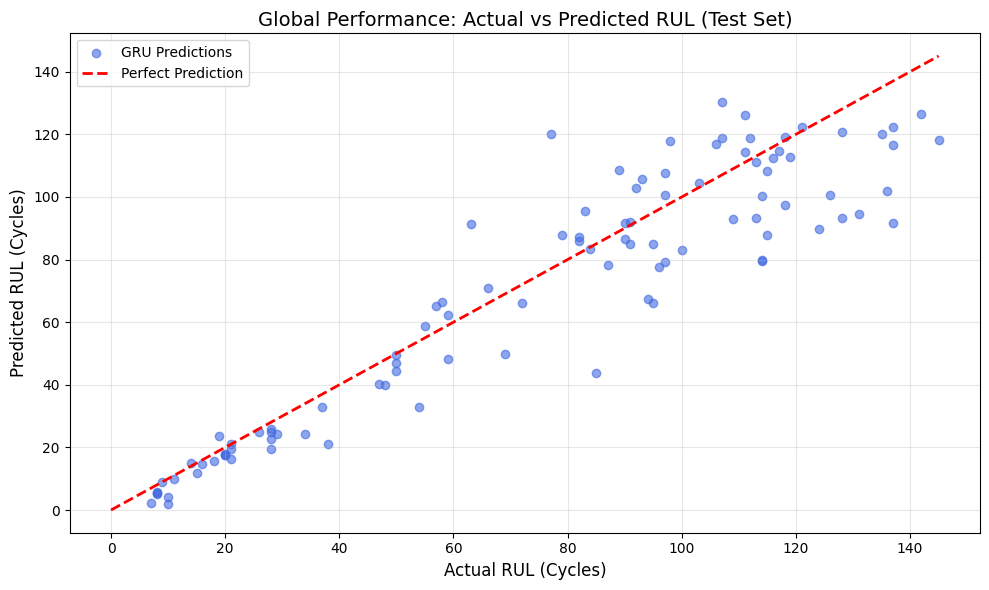

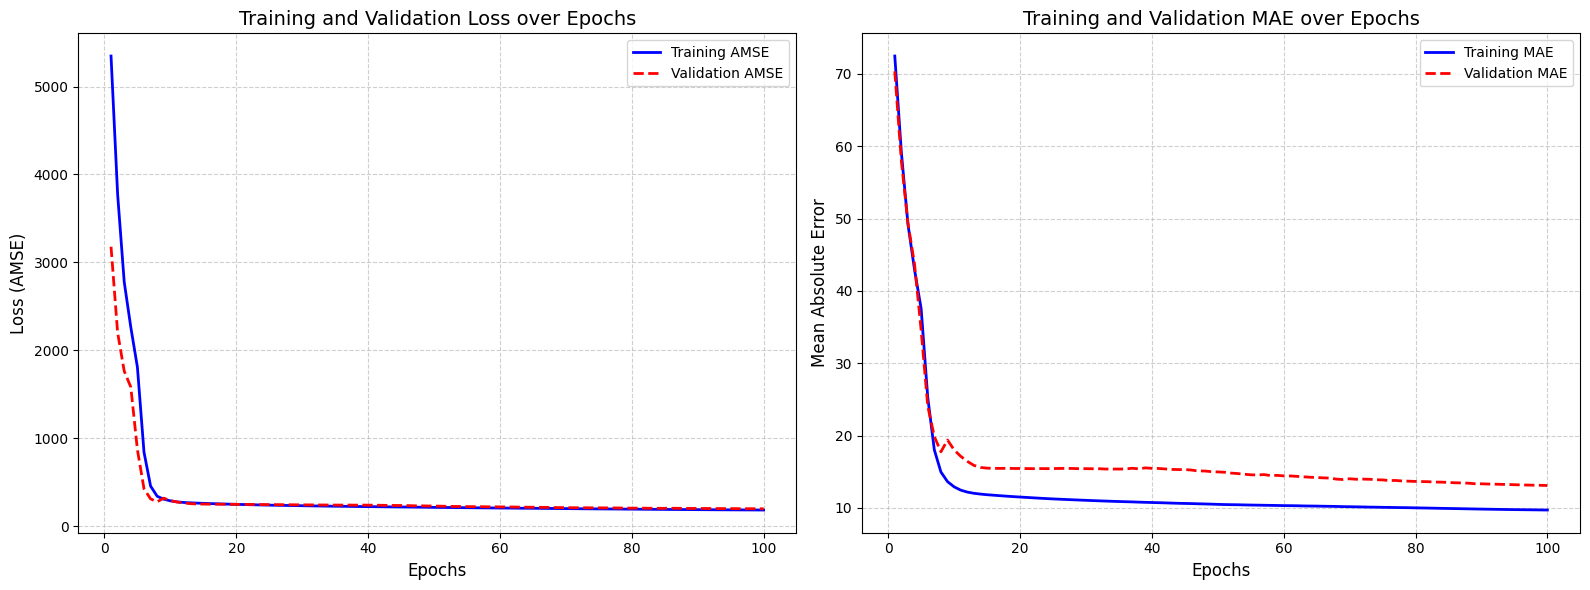

In [36]:
# ---------------------------------------------------------
# 10. Visualization Functions & Execution
# ---------------------------------------------------------
def plot_sorted_rul(y_true, y_pred, title):
    sort_indices = np.argsort(y_true)
    y_true_sorted = y_true[sort_indices]
    y_pred_sorted = y_pred[sort_indices]

    plt.figure(figsize=(12, 6))
    plt.plot(y_pred_sorted, color='blue', alpha=0.6, label='Predicted RUL')
    plt.plot(y_true_sorted, color='red', linewidth=2, label='Target RUL')
    plt.title(title, fontsize=14)
    plt.xlabel('Samples (Sorted by Target RUL)', fontsize=12)
    plt.ylabel('Remaining Useful Life (Cycles)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_actual_vs_predicted(y_true, y_pred, title, alpha):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=alpha, color='royalblue', label='GRU Predictions')
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    plt.title(title, fontsize=14)
    plt.xlabel('Actual RUL (Cycles)', fontsize=12)
    plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_learning_curves(history):
    mse = history.history['loss']
    val_mse = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(mse) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(epochs, mse, 'b-', linewidth=2, label='Training AMSE')
    ax1.plot(epochs, val_mse, 'r--', linewidth=2, label='Validation AMSE')
    ax1.set_title('Training and Validation Loss over Epochs', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss (AMSE)', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(epochs, mae, 'b-', linewidth=2, label='Training MAE')
    ax2.plot(epochs, val_mae, 'r--', linewidth=2, label='Validation MAE')
    ax2.set_title('Training and Validation MAE over Epochs', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Mean Absolute Error', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Generate all final plots
plot_sorted_rul(y_train, y_train_pred_gru_es, 'Train Data: Target vs. Predicted RUL (GRU + ES)')
plot_sorted_rul(y_test, y_test_pred_gru_es, 'Test Data: Target vs. Predicted RUL (GRU + ES)')
plot_actual_vs_predicted(y_train, y_train_pred_gru_es, 'Global Performance: Actual vs Predicted RUL (Train Set)', 0.1)
plot_actual_vs_predicted(y_test, y_test_pred_gru_es, 'Global Performance: Actual vs Predicted RUL (Test Set)', 0.6)
plot_learning_curves(history)

## Comparison of performance

In [40]:
# ---------------------------------------------------------
# Final Project Comparison Table Generator
# ---------------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # Run this right before the comparison table code
# y_test_pred_rnn = model_rnn.predict(x_test).reshape(-1)
# y_test_pred_lstm = model_lstm.predict(x_test).reshape(-1)

# Helper function to calculate test metrics
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

# Calculate metrics for all three architectures (Test Data Only)
metrics_rnn = get_metrics(y_test, y_test_pred_rnn)   # Replace with your actual basic RNN predictions
metrics_lstm = get_metrics(y_test, y_test_pred_lstm) # Replace with your actual LSTM predictions
metrics_gru = get_metrics(y_test, y_test_pred_gru)   # From the code block above
metrics_gru_es = get_metrics(y_test, y_test_pred_gru_es)

# Compile into a Pandas DataFrame
comparison_df = pd.DataFrame({
    'Architecture': ['Basic RNN', 'LSTM', 'GRU', 'GRU+ES'],
    'Test MSE': [metrics_rnn[0], metrics_lstm[0], metrics_gru[0], metrics_gru_es[0]],
    'Test MAE': [metrics_rnn[1], metrics_lstm[1], metrics_gru[1], metrics_gru_es[1]],
    'Test R2 Score': [metrics_rnn[2], metrics_lstm[2], metrics_gru[2], metrics_gru_es[2]]
})

print("\n--- Final Architecture Comparison (Test Set) ---")
print(comparison_df.to_markdown(index=False, floatfmt=".4f"))


--- Final Architecture Comparison (Test Set) ---
| Architecture   |   Test MSE |   Test MAE |   Test R2 Score |
|:---------------|-----------:|-----------:|----------------:|
| Basic RNN      |   367.0650 |    13.1527 |          0.7874 |
| LSTM           |   318.9114 |    12.4231 |          0.8153 |
| GRU            |   301.5103 |    12.7503 |          0.8254 |
| GRU+ES         |   256.1612 |    11.5161 |          0.8517 |


In [41]:
metrics_rnn = get_metrics(y_test, y_test_pred_rnn)
metrics_lstm = get_metrics(y_test, y_test_pred_lstm)
metrics_gru = get_metrics(y_test, y_test_pred_gru)

comparison_df = pd.DataFrame({
    'Architecture': ['Basic RNN', 'LSTM (AMSE)', 'GRU (AMSE)'],
    'Test MSE': [metrics_rnn[0], metrics_lstm[0], metrics_gru[0]],
    'Test MAE': [metrics_rnn[1], metrics_lstm[1], metrics_gru[1]],
    'Test R2 Score': [metrics_rnn[2], metrics_lstm[2], metrics_gru[2]]
})

print("\n--- Final Architecture Comparison (Test Set) ---")
print(comparison_df.to_markdown(index=False, floatfmt=".4f"))


--- Final Architecture Comparison (Test Set) ---
| Architecture   |   Test MSE |   Test MAE |   Test R2 Score |
|:---------------|-----------:|-----------:|----------------:|
| Basic RNN      |   367.0650 |    13.1527 |          0.7874 |
| LSTM (AMSE)    |   318.9114 |    12.4231 |          0.8153 |
| GRU (AMSE)     |   301.5103 |    12.7503 |          0.8254 |


In [48]:
# ---------------------------------------------------------
# Updated Final Architecture Comparison Table
# ---------------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Helper function to calculate all metrics, including over-estimates
def get_comprehensive_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Calculate Over-estimates
    # y_pred > y_true creates a boolean array. np.sum() counts the 'True' values.
    over_count = np.sum(y_pred > y_true)
    over_pct = (over_count / len(y_true)) * 100

    return mse, mae, r2, over_count, over_pct

# Calculate metrics for all three architectures
# (Assumes y_test_pred_rnn and y_test_pred_lstm are saved in memory from your earlier runs)
metrics_rnn = get_comprehensive_metrics(y_test, y_test_pred_rnn)
metrics_lstm = get_comprehensive_metrics(y_test, y_test_pred_lstm)
metrics_gru = get_comprehensive_metrics(y_test, y_test_pred_gru)
metrics_gru_es = get_comprehensive_metrics(y_test, y_test_pred_gru_es)

# Compile into a Pandas DataFrame
comparison_df = pd.DataFrame({
    'Architecture': ['Basic RNN (MSE)', 'LSTM (AMSE)', 'GRU (AMSE)', 'GRU (AMSE + ES)'],
    'Test MSE': [round(metrics_rnn[0], 4), round(metrics_lstm[0], 4), round(metrics_gru[0], 4), round(metrics_gru_es[0], 4)],
    'Test MAE': [round(metrics_rnn[1], 4), round(metrics_lstm[1], 4), round(metrics_gru[1], 4), round(metrics_gru_es[1], 4)],
    'Test R2 Score': [round(metrics_rnn[2], 4), round(metrics_lstm[2], 4), round(metrics_gru[2], 4), round(metrics_gru_es[2], 4)],
    'Over-estimates (#)': [int(metrics_rnn[3]), int(metrics_lstm[3]), int(metrics_gru[3]), int(metrics_gru_es[3])],
    'Over-estimates (%)': [f"{metrics_rnn[4]:.2f}%", f"{metrics_lstm[4]:.2f}%", f"{metrics_gru[4]:.2f}%", f"{metrics_gru_es[4]:.2f}%"]
})

print("\n--- Final Architecture Comparison (Test Set) ---")
print(comparison_df.to_markdown(index=False))


--- Final Architecture Comparison (Test Set) ---
| Architecture    |   Test MSE |   Test MAE |   Test R2 Score |   Over-estimates (#) | Over-estimates (%)   |
|:----------------|-----------:|-----------:|----------------:|---------------------:|:---------------------|
| Basic RNN (MSE) |    367.065 |    13.1527 |          0.7874 |                   54 | 54.00%               |
| LSTM (AMSE)     |    318.911 |    12.4231 |          0.8153 |                   30 | 30.00%               |
| GRU (AMSE)      |    301.51  |    12.7503 |          0.8254 |                   26 | 26.00%               |
| GRU (AMSE + ES) |    256.161 |    11.5161 |          0.8517 |                   31 | 31.00%               |


To do:  

- feel like I have to penalize over-estimates wayyyy more  
- try early stopping for lstm & perhaps basic RNN  
- try pinball loss?

## Download as PDF code